# Concise Implementation of Linear Regression


High Level APIs

In [74]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In PyTorch, the fully connected layer is defined in `Linear` and `LazyLinear` classes (available since version 1.8.0). 
The latter
allows users to specify *merely*
the output dimension,
while the former
additionally asks for
how many inputs go into this layer.
Specifying input shapes is inconvenient and may require nontrivial calculations
(such as in convolutional layers).
Thus, for simplicity, we will use such "lazy" layers
whenever we can.


In [63]:
class LinearRegression(d2l.Module):  #@save
    """The linear regression model implemented with high-level APIs."""
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

In the `forward` method we just invoke the built-in `__call__` method of the predefined layers to compute the outputs.


In [64]:
@d2l.add_to_class(LinearRegression)  #@save
def forward(self, X):
    return self.net(X)

[**The `MSELoss` class computes the mean squared error (without the $1/2$ factor).**]


By default, `MSELoss` returns the average loss over examples.


It is faster (and easier to use) than implementing our own.
                                                    

In [109]:
@d2l.add_to_class(LinearRegression)  #@save
def loss(self, y_hat, y):
    fn = nn.MSELoss()
    return fn(y_hat, y)

Minibatch SGD is a standard tool
for optimizing neural networks
and thus PyTorch supports it alongside a number of
variations on this algorithm in the `optim` module.
When we (**instantiate an `SGD` instance,**)
we specify the parameters to optimize over,
obtainable from our model via `self.parameters()`,
and the learning rate (`self.lr`)
required by our optimization algorithm.


In [108]:
@d2l.add_to_class(LinearRegression)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)

Training

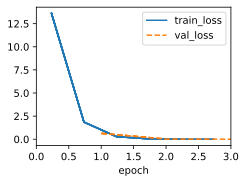

In [83]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [98]:
@d2l.add_to_class(LinearRegression)  #@save
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)
w, b = model.get_w_b()

In [69]:
print(f'error in estimating w: {data.w - w.reshape(data.w.shape)}')
print(f'error in estimating b: {data.b - b}')

error in estimating w: tensor([ 0.0075, -0.0046])
error in estimating b: tensor([0.0093])


In PyTorch, the `data` module provides tools for data processing,
the `nn` module defines a large number of neural network layers and common loss functions.


We can initialize the parameters by replacing their values
with methods ending with `_`.


Example:

In [ ]:
# In PyTorch, a method ending with _ modifies the tensor in place
x = torch.tensor([1., 2.])

x.fill_(5)

print(x)  # tensor([5., 5.])

tensor([5., 5.])


In [ ]:
x.normal_(0, 0.01)  # replace values with random normal values
# model.net.bias.fill_(0)            # replace every value with 0
# The underscore is simply PyTorch’s convention meaning modify the tensor itself

tensor([-0.0099,  0.0002])

Note that we need to specify the input dimensions of the network.

While this is trivial for now, it can have significant knock-on effects
when we want to design complex networks with many layers.


Careful considerations of how to parametrize these networks
is needed to allow portability.

## Exercises

1. How would you need to change the learning rate if you replace the aggregate loss over the minibatch
   with an average over the loss on the minibatch?
1. Review the framework documentation to see which loss functions are provided. In particular,
   replace the squared loss with Huber's robust loss function. That is, use the loss function
   $$l(y,y') = \begin{cases}|y-y'| -\frac{\sigma}{2} & \textrm{ if } |y-y'| > \sigma \\ \frac{1}{2 \sigma} (y-y')^2 & \textrm{ otherwise}\end{cases}$$
1. How do you access the gradient of the weights of the model?
1. What is the effect on the solution if you change the learning rate and the number of epochs? Does it keep on improving?
1. How does the solution change as you vary the amount of data generated?
    1. Plot the estimation error for $\hat{\mathbf{w}} - \mathbf{w}$ and $\hat{b} - b$ as a function of the amount of data. Hint: increase the amount of data logarithmically rather than linearly, i.e., 5, 10, 20, 50, ..., 10,000 rather than 1000, 2000, ..., 10,000.
    2. Why is the suggestion in the hint appropriate?


2. Implementing the loss

In [106]:
import torch.nn.functional as F
@d2l.add_to_class(LinearRegression)
def loss(self, y_hat, y, sigma=0.01):
    y = y.reshape(y_hat.shape)

# Theres F.smooth_l1_loss &&  F.huber_loss
# They are just different scaled versions
# The books version is the smooth one  
    return F.smooth_l1_loss(y_hat, y, beta=sigma, reduction="mean")

We notice that the average loss decreass rapidly with `MSE` unlike `Hubert Loss`

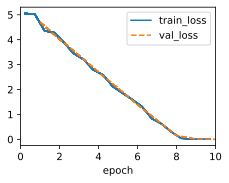

In [86]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

3. We use:

In [92]:
# Grad respecting weight, bias
model.net.weight.grad, model.net.bias.grad

(tensor([[-0.1401,  0.0543]]), tensor([-0.0027]))

4.

- Small learning rate: stable but requires more epochs.

- Suitable (Subjective) learning rate: converges quickly.

- Excessive learning rate: oscillates or diverges.

- More epochs help only until convergence.

Validation error can eventually worsen because of overfitting.

Aka training doesn't improve indefinitely.

5.

In [119]:
import matplotlib.pyplot as plt

true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

epoch = 10
sizes = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

w_errors = []
b_errors = []

for n in sizes:
    data = d2l.SyntheticRegressionData(
        w=true_w,
        b=true_b,
        num_train=n,
        num_val=100,
        batch_size=min(32, n)
    )

    model = LinearRegression(lr=0.03)
    model.board.display = False

    trainer = d2l.Trainer(max_epochs=epoch)
    trainer.fit(model, data)

    estimated_w = model.net.weight.detach().reshape(-1)
    estimated_b = model.net.bias.detach().item()

    w_errors.append(torch.linalg.vector_norm(
        estimated_w - true_w
    ).item())

    b_errors.append(abs(estimated_b - true_b))

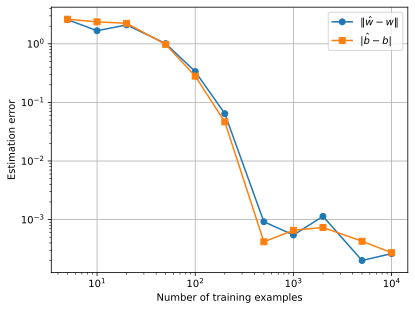

In [123]:
plt.loglog(sizes, w_errors, "o-", label=r"$\|\hat{w}-w\|$")
plt.loglog(sizes, b_errors, "s-", label=r"$|\hat{b}-b|$")

plt.xlabel("Number of training examples")
plt.ylabel("Estimation error")
plt.legend()
plt.grid(True)
plt.show()

Generally, more data reduces estimation error, although individual results fluctuate randomly.

The higher the number of epoch the more the error fluctuates when the number of examples is high.

Here we notice that the sweet spot is aroung $10^3$.

Retraining (Rerunning the code) here gives us variable results depending on the data.

- **Why Logarithmic?**

The range $5–10{,}000$ spans several orders of magnitude.

Logarithmic spacing shows changes at both small and large dataset sizes without wasting most measurements near $10{,}000$.